In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
inspection.inspect_model('resnet101')

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

conv1: Conv2d
bn1: BatchNorm2d
act1: ReLU
maxpool: MaxPool2d
layer1: Sequential
layer1.0: Bottleneck
layer1.0.conv1: Conv2d
layer1.0.bn1: BatchNorm2d
layer1.0.act1: ReLU
layer1.0.conv2: Conv2d
layer1.0.bn2: BatchNorm2d
layer1.0.drop_block: Identity
layer1.0.act2: ReLU
layer1.0.aa: Identity
layer1.0.conv3: Conv2d
layer1.0.bn3: BatchNorm2d
layer1.0.act3: ReLU
layer1.0.downsample: Sequential
layer1.0.downsample.0: Conv2d
layer1.0.downsample.1: BatchNorm2d
layer1.1: Bottleneck
layer1.1.conv1: Conv2d
layer1.1.bn1: BatchNorm2d
layer1.1.act1: ReLU
layer1.1.conv2: Conv2d
layer1.1.bn2: BatchNorm2d
layer1.1.drop_block: Identity
layer1.1.act2: ReLU
layer1.1.aa: Identity
layer1.1.conv3: Conv2d
layer1.1.bn3: BatchNorm2d
layer1.1.act3: ReLU
layer1.2: Bottleneck
layer1.2.conv1: Conv2d
layer1.2.bn1: BatchNorm2d
layer1.2.act1: ReLU
layer1.2.conv2: Conv2d
layer1.2.bn2: BatchNorm2d
layer1.2.drop_block: Identity
layer1.2.act2: ReLU
layer1.2.aa: Identity
layer1.2.conv3: Conv2d
layer1.2.bn3: BatchNorm2d
lay

In [2]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='37', run_id='db78ec6b787f4e58afa381c85f51f94a')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1586.)
  tensor = torch.frombuffer(


Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:37//data/model.pt2


In [3]:
model.predict(torch.randn(1,3,512,256))

(1548.199951171875,
 tensor([[[0.0054, 0.0071, 0.0084,  ..., 0.0060, 0.0038, 0.0017],
          [0.0067, 0.0096, 0.0110,  ..., 0.0085, 0.0062, 0.0030],
          [0.0076, 0.0107, 0.0121,  ..., 0.0106, 0.0084, 0.0040],
          ...,
          [0.0012, 0.0005, 0.0007,  ..., 0.0031, 0.0025, 0.0019],
          [0.0010, 0.0007, 0.0006,  ..., 0.0017, 0.0017, 0.0017],
          [0.0007, 0.0007, 0.0005,  ..., 0.0011, 0.0008, 0.0011]]]))

In [4]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

In [5]:
model.evaluate(datamodule)

tensor([603.6976]) tensor([171.8294])
tensor([506.9579]) tensor([497.0636])
tensor([432.9360]) tensor([381.9256])
tensor([655.6742]) tensor([210.3973])
tensor([260.8254]) tensor([217.3769])
tensor([552.5197]) tensor([427.6055])
tensor([1513.0195]) tensor([1163.2383])
tensor([236.9897]) tensor([257.0872])
tensor([1059.9908]) tensor([1225.8103])
tensor([203.9729]) tensor([288.4334])
tensor([240.2566]) tensor([175.6181])
tensor([402.6632]) tensor([373.5144])
tensor([1076.2903]) tensor([1063.9664])
tensor([811.8422]) tensor([1016.6429])
tensor([570.3663]) tensor([448.3900])
tensor([440.5963]) tensor([254.8806])
tensor([579.6591]) tensor([65.9953])
tensor([330.6828]) tensor([140.8374])
tensor([1131.7910]) tensor([1183.6310])
tensor([389.7020]) tensor([284.3199])
tensor([1688.2717]) tensor([1588.7800])
tensor([275.8885]) tensor([237.5375])
tensor([297.6441]) tensor([244.3082])
tensor([187.8159]) tensor([319.3656])
tensor([126.9512]) tensor([130.5617])
tensor([1302.7153]) tensor([1204.2679])


{'MAE': 83.7930679321289, 'MSE': 17616.57421875, 'NAE': 0.2635510563850403}

In [29]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [30]:
result_count, result  = model.predict(sample)
(result_count, result)

(1513.01953125,
 tensor([[[0.0008, 0.0006, 0.0006,  ..., 0.0009, 0.0008, 0.0007],
          [0.0006, 0.0006, 0.0006,  ..., 0.0011, 0.0009, 0.0007],
          [0.0006, 0.0005, 0.0005,  ..., 0.0013, 0.0012, 0.0009],
          ...,
          [0.0003, 0.0002, 0.0001,  ..., 0.0003, 0.0003, 0.0004],
          [0.0004, 0.0002, 0.0002,  ..., 0.0003, 0.0004, 0.0006],
          [0.0005, 0.0004, 0.0004,  ..., 0.0003, 0.0004, 0.0006]]]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


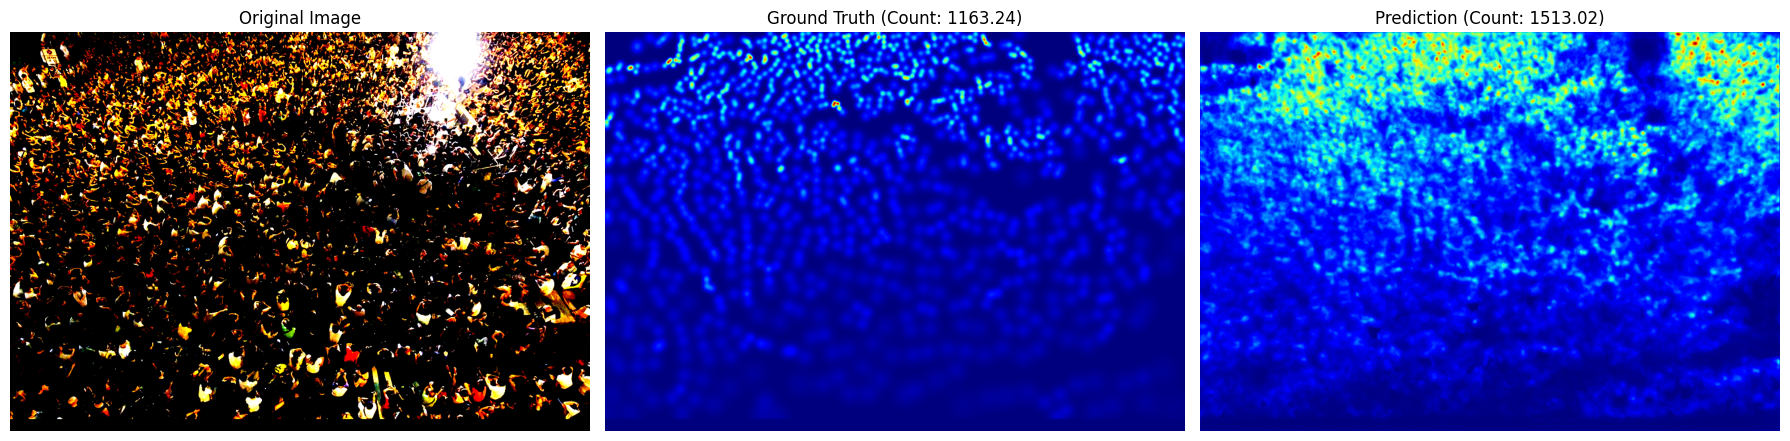

In [31]:
vis.visualize_sample(sample, target, result, count, result_count, )

In [9]:
from src.models.model import CrowdCounter


crowd_model = CrowdCounter(params=params)
# crowd_model.load_state_dict(model.model.state_dict())
crowd_model.eval()

CrowdCounter(
  (net): UNet(
    (net): Unet(
      (encoder): EfficientNetEncoder(
        (_conv_stem): Conv2dStaticSamePadding(
          3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
          (static_padding): ZeroPad2d((0, 1, 0, 1))
        )
        (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_blocks): ModuleList(
          (0): MBConvBlock(
            (_expand_conv): Identity()
            (_bn0): Identity()
            (_depthwise_conv): Conv2dStaticSamePadding(
              32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
              (static_padding): ZeroPad2d((1, 1, 1, 1))
            )
            (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
            (_se_reduce): Conv2dStaticSamePadding(
              32, 8, kernel_size=(1, 1), stride=(1, 1)
              (static_padding): Identity()
            )
            (_se_

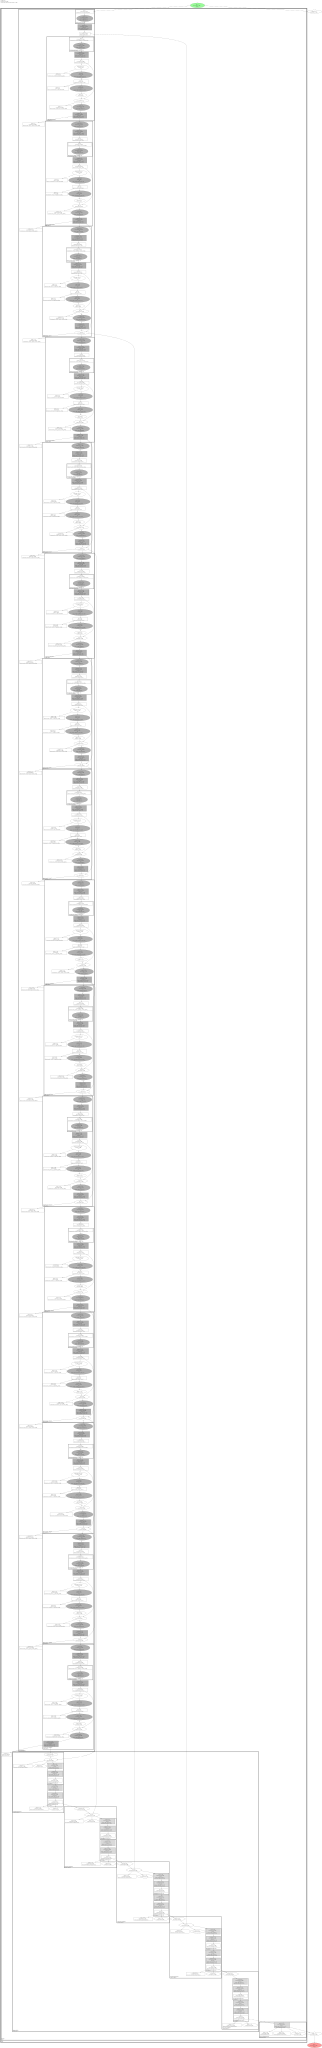

[Errno 2] No such file or directory: 'xdg-open'


In [11]:
vis.visualize_model_graph(crowd_model, sample=sample)